In [1]:
import mne

In [2]:
edf_file_path =r"D:\sara alipore\sara alipore\Siamak Ghafari_002\Ghafari_002_EEG.edf"

In [3]:
raw = mne.io.read_raw_edf(edf_file_path, preload=True)

Extracting EDF parameters from D:\sara alipore\sara alipore\Siamak Ghafari_002\Ghafari_002_EEG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 79499  =      0.000 ...   317.996 secs...


In [4]:
print("data information")
print(raw.info)

data information
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-AA, EEG Fp2-AA, EEG F7-AA, EEG F3-AA, EEG Fz-AA, EEG ...
 chs: 20 EEG
 custom_ref_applied: False
 highpass: 1.6 Hz
 lowpass: 30.0 Hz
 meas_date: 2026-06-27 12:49:34 UTC
 nchan: 20
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: 000137, sex: 0, last_name: Ghafari, birthday: 2004-06-02>
>


In [8]:

raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-AA', '').strip())

print("New_Name")
print(raw.ch_names)

# 3. Specify that 'event' is a stimulus channel, not an EEG channel
raw.set_channel_types({'event': 'stim'})

# 4. Apply standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

print("Channel Types:")
print(raw.get_channel_types())

print("\nMontage successfully set! 🎯")

New_Name
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'T6', 'O1', 'O2', 'event']
Channel Types:
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']

Montage successfully set! 🎯


In [11]:


# 2. Clean channel names & set channel types
raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-AA', '').strip())
raw.set_channel_types({'event': 'stim'})

# 3. Apply standard 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

# 4. Check for embedded annotations/events
print("=== Annotations in Data ===")
print(raw.annotations)

# 5. Plot 20 seconds of continuous EEG signal
# Scaled appropriately for EEG (nchan=19 EEG channels)
raw.plot(duration=20.0, n_channels=19, scalings='auto', title='EEG Raw Data Inspection')

=== Annotations in Data ===
<Annotations | 1 segment: 12:49:34 PM Eyes closed (1)>
Using qt as 2D backend.


In [12]:
raw_filtered = raw.copy().filter(l_freq= 2.0 , h_freq=30.0 )

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 2 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



In [13]:
# 3. Plot Raw vs Filtered Signal (20 seconds)
raw.plot(duration=20.0, n_channels=19, scalings='auto', title='1. Before Filtering (Raw)')
raw_filtered.plot(duration=20.0, n_channels=19, scalings='auto', title='2. After Bandpass Filter (2-30 Hz)')

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 6.1s.


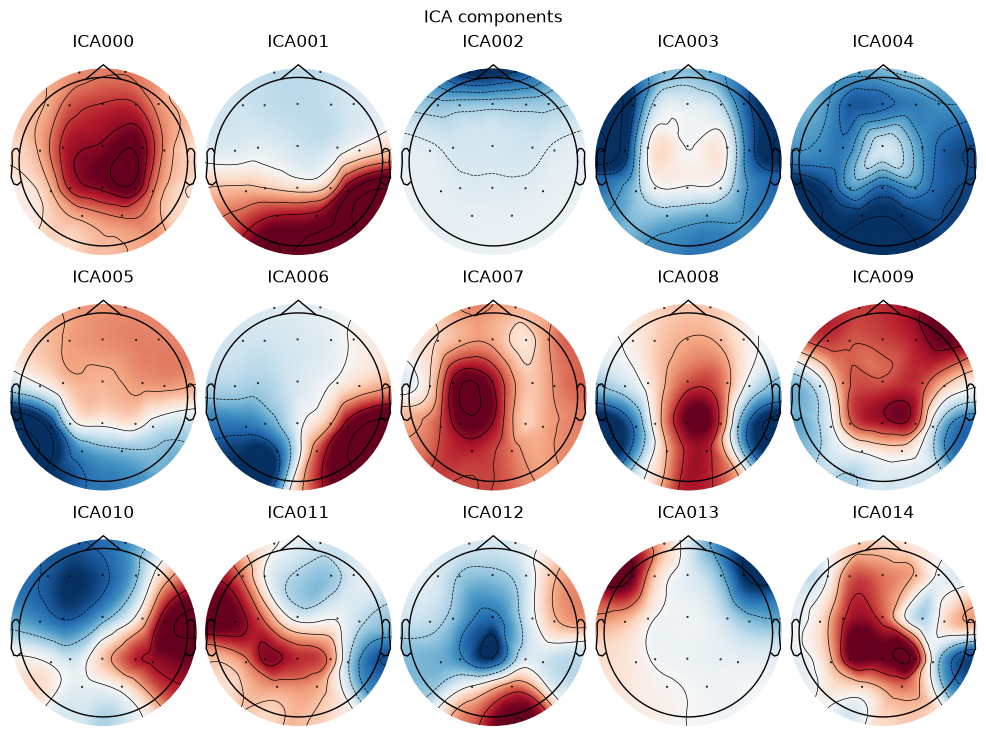

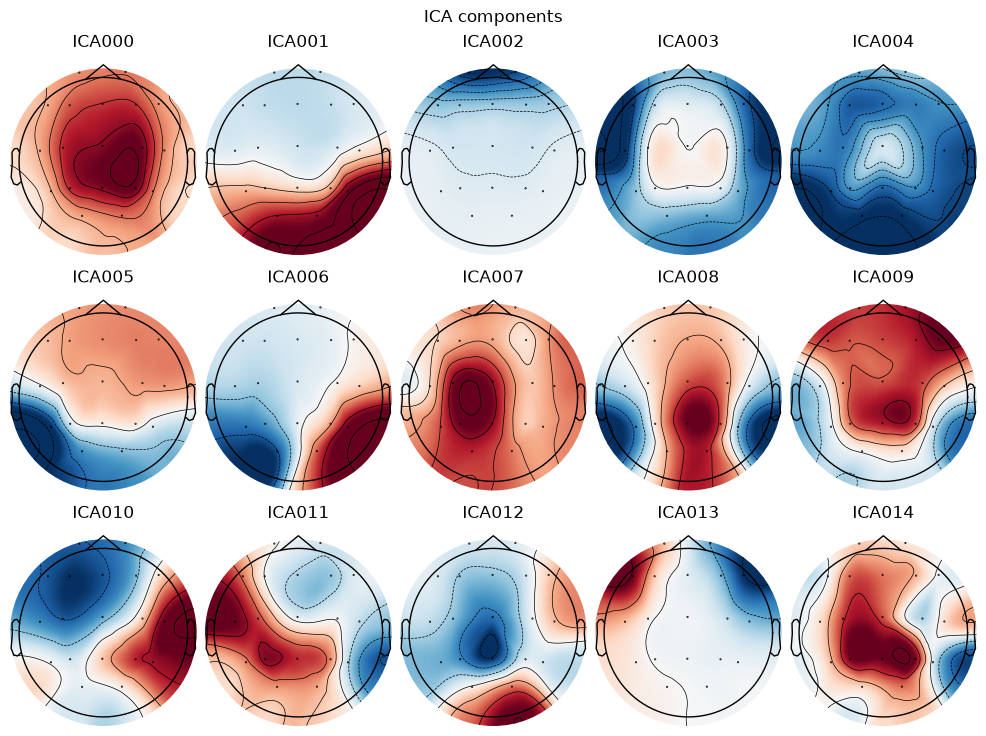

In [15]:
from mne.preprocessing import ICA
# 3. Setup and fit ICA
# We choose 15 components for 19 EEG channels
ica = ICA(n_components=15, max_iter='auto', random_state=97)
ica.fit(raw_filtered)

# 4. Plot 2D spatial maps of components
ica.plot_components()

In [16]:
# 1. Choose the noise component index to exclude
# ICA002 is index 2
ica.exclude = [2]

# 2. Apply ICA clean-up to raw data
raw_cleaned = raw_filtered.copy()
ica.apply(raw_cleaned)

# 3. Plot cleaned continuous EEG
raw_cleaned.plot(duration=20.0, n_channels=19, scalings='auto', title='EEG Signal After ICA Cleaning')

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 19 PCA components


Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 19 PCA components


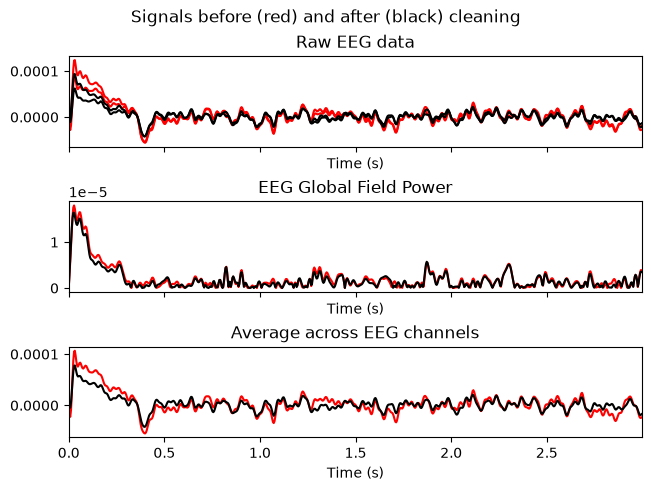

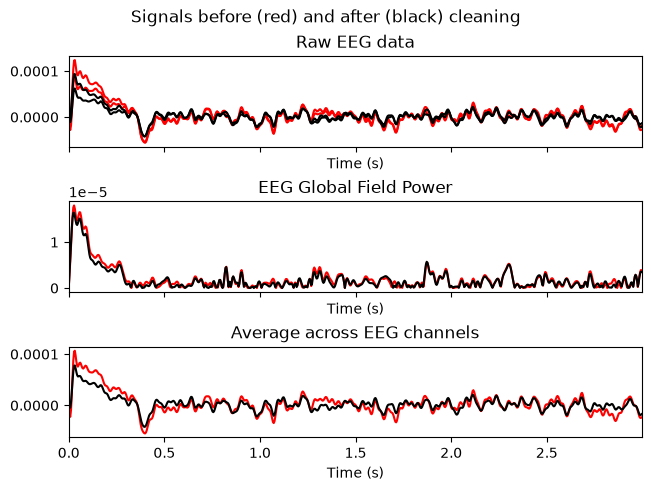

In [17]:
# Overlay signal before and after ICA to verify clean-up
ica.plot_overlay(raw_filtered, exclude=[2], picks=['Fp1', 'Fp2'])

In [18]:
# Apply average reference to the cleaned raw data
raw_cleaned.set_eeg_reference(ref_channels='average', projection=False)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | Ghafari_002_EEG.edf, 20 x 79500 (318.0 s), ~12.2 MiB, data loaded>